# Neural Network Project - Image Classification on CIFAR-10

- The CIFAR-10 dataset is a challenging benchmark dataset for image classification. It contains 60,000 32x32 color images across 10 classes (e.g airplane, car, bird, dog)
- Unilike MNIST, CIFAR-10 involes more complex patterns and requires robust neural network architectures

Key Steps:
- Preprocess the dataset for training (e.g, normalization, One-hot encoding)
- Define a neural network with Convolutional layers from feature extraction
- Optimize the network using technique like learning rate adjustment and dropout

### Analyzing Model Performance and Experimenting with Hyperparameter Tuning

Performance Analysis
- Evaluate accuracy and loss curves during training
- Use test set metrics to measure generalization
  
Experimantation
 - Try different activation function (e.g ReLU, Tanh)
 - Test optimizers like SGD, Adam and RMSprop
 - Adjust the learning rate and regularization technique (e.g dropout weight decay)

Hands-on Project

Objective: Build, train, and optimize a neural netwoek for CIFAR-10 image classification, experimenting with hyperparameters to improve perforamnce

In [25]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


# To visualise the entire training process
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(X_train, y_train),(X_test, y_test) = cifar10.load_data()

# Normailise pixel values to [0,1]
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0


In [11]:
# One-hot encoding target labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Trainng data shape:{X_train.shape}, {y_train.shape}")
print(f"Testing data shape:{X_test.shape},{y_test.shape}")

Trainng data shape:(50000, 32, 32, 3), (50000, 10)
Testing data shape:(10000, 32, 32, 3),(10000, 10)


In [12]:
# Define the baseline model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
    
])

C:\Users\priya\OneDrive\Desktop\ML Sangrah\MLSangrah\mlenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
# Display the model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the aeline model
history = model.fit(
    X_train, y_train, 
    validation_split = 0.2,
    epochs = 10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.3861 - loss: 1.6761 - val_accuracy: 0.5205 - val_loss: 1.3591
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5082 - loss: 1.3790 - val_accuracy: 0.5773 - val_loss: 1.2136
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.5547 - loss: 1.2595 - val_accuracy: 0.6096 - val_loss: 1.1190
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.5855 - loss: 1.1711 - val_accuracy: 0.6358 - val_loss: 1.0570
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6111 - loss: 1.1055 - val_accuracy: 0.6279 - val_loss: 1.0469
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6314 - loss: 1.0460 - val_accuracy: 0.6527 - val_loss: 0.9871
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.6476 - loss: 1.0018 - val_accuracy: 0.6718 - val_loss: 0.9380
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.6625 - loss: 0.9590 - 

In [16]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Model Test Accuracy:{accuracy:.4f}")

Baseline Model Test Accuracy:0.6876


---

In [19]:
# Define the improved model

improved_model = Sequential([
    Conv2D(64, (5, 5), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2,2)),
    Conv2D(128, (5,5), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
    
])

C:\Users\priya\OneDrive\Desktop\ML Sangrah\MLSangrah\mlenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Complie the improved model with learning rate scheduler
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
improved_model.compile(optimizer=optimizer, loss='categorical_crossentropy',metrics=['accuracy'])

In [21]:
# Train the improved model
improved_history = improved_model.fit(
    X_train, y_train, 
    validation_split = 0.2,
    epochs = 20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 79ms/step - accuracy: 0.3985 - loss: 1.6416 - val_accuracy: 0.5103 - val_loss: 1.3565
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.5373 - loss: 1.2996 - val_accuracy: 0.5910 - val_loss: 1.1480
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.5926 - loss: 1.1466 - val_accuracy: 0.6301 - val_loss: 1.0415
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 114ms/step - accuracy: 0.6356 - loss: 1.0372 - val_accuracy: 0.6439 - val_loss: 1.0183
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6625 - loss: 0.9599 - val_accuracy: 0.6677 - val_loss: 0.9499
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.6851 - loss: 0.8913 - val_accuracy: 0.6748 - val_loss: 0.9337
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.7063 - loss: 0.8337 - val_accuracy: 0.6958 - val_loss: 0.8914
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 88ms/step - accuracy: 0.7255 - loss: 0.7778 

In [23]:
# Evaluat the improved model

improved_loss, improved_accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print(f"Improved Model Test Accuracy:{improved_accuracy:.4f}")

Improved Model Test Accuracy:0.7013


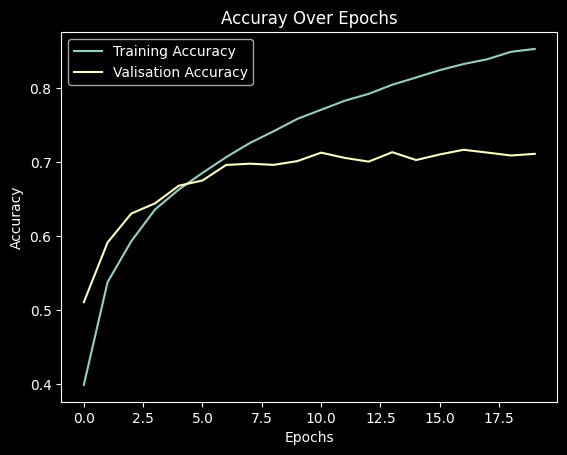

In [26]:
# Plot training and validation accuracy
plt.plot(improved_history.history['accuracy'],label="Training Accuracy")
plt.plot(improved_history.history['val_accuracy'],label="Valisation Accuracy") 
plt.title('Accuray Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

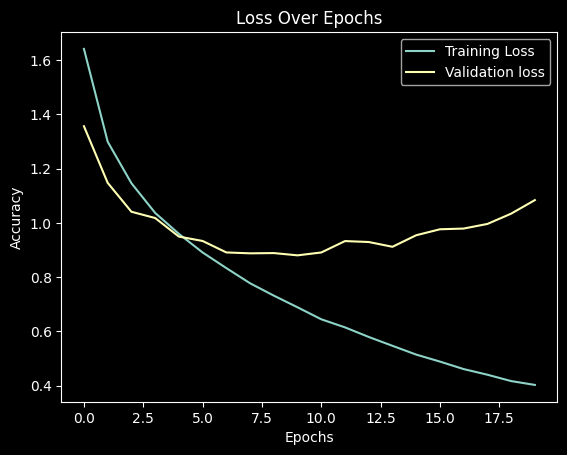

In [27]:
# Plot training and validation accuracy
plt.plot(improved_history.history['loss'],label="Training Loss")
plt.plot(improved_history.history['val_loss'],label="Validation loss") 
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()